<a href="https://colab.research.google.com/github/Manjushreetr/Manjushree_Labmentix/blob/Amazon-Prime-EDA/Amazon_Prime_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA_Amazon Prime EDA


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member -** - Manjushree T R


# **Project Summary -**

Objective
The primary goal of this project is to analyze the Amazon Prime movie dataset to gain insights into the platforms content distribution, identify key actors and directors, and examine IMDb ratings to understand trends in movie quality.

# **GitHub Link -**

# **Problem Statement**


This analysis explores the shows available on Amazon Prime Video, providing valuable insights such as:
Content Diversity: Identifying the dominant genres and categories on the platform.
Regional Availability: Understanding how content distribution varies across different regions.
Trends Over Time: Examining how Amazon Prime's content library has evolved.
IMDb Ratings & Popularity: Identifying the highest-rated and most popular shows.


#### **Define Your Business Objective?**

By analyzing this dataset, businesses, content creators, and data analysts can uncover key trends that impact subscription growth, user engagement, and content investment strategies in the streaming industry.

# EDA Analysis


## ***1. Know Your Data***

#### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
from wordcloud import WordCloud

### Preprocessing
#### Exploring data

In [3]:
df_credits= pd.read_csv(r'/content/credits..csv', encoding='utf-8')
df_titles= pd.read_csv(r'/content/titles..csv')

In [4]:
df_credits.shape

(124235, 5)

In [5]:
df_credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [6]:
df_credits.id.nunique()

8861

There is no unique variable in data frame 1.

In [7]:
df_credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


## ***2. Understanding Your Variables***

1. person_id - The  person id column can be used for visualization.
2. id - The id column can be used as primary key column.
3. name - This field is not helpfull we can ignore this field.
4. character - This column is important to create visuals.
5. role - It is useful since we can classify the roles.

Exploring data

In [8]:
df_titles.shape

(9871, 15)

In [9]:
df_titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [10]:
df_titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


Duplicate Values

In [11]:
df_titles.id.nunique()

9868

In [12]:
duplicate_df_titles_ids = df_titles[df_titles.duplicated(subset=['id'], keep=False)]

In [13]:
duplicate_df_titles_ids

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
479,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
718,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
719,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [14]:
df_titlescleaned = df_titles.drop_duplicates(subset=['id'], keep='first')

In [15]:
df_titlescleaned['production_countries']= df_titlescleaned['production_countries'].str.replace("'", "").str.replace('[', '').str.replace(']', '')

<ipython-input-15-1820f57f8f60>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titlescleaned['production_countries']= df_titlescleaned['production_countries'].str.replace("'", "").str.replace('[', '').str.replace(']', '')


In [16]:
df_exploded_production_countries = df_titlescleaned.assign(production_countries=df_titlescleaned["production_countries"].str.split(", ")).explode("production_countries")

In [17]:
df_exploded_production_countries

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",US,NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",US,NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",US,NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",US,NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],US,NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],US,NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],IN,NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",,NaN,tt14331982,8.4,49.0,0.645,NaN


In [18]:
df_titlescleaned['genres']= df_titlescleaned['genres'].str.replace("'", "").str.replace('[', '').str.replace(']', '').replace('','Unknown')

<ipython-input-18-48037f532028>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_titlescleaned['genres']= df_titlescleaned['genres'].str.replace("'", "").str.replace('[', '').str.replace(']', '').replace('','Unknown')


In [19]:
df_titlescleaned['genres'].reset_index()

,index,genres
0,0,"comedy, family, animation, action, fantasy, ho..."
1,1,"action, drama, war, western, comedy, european"
2,2,"romance, war, drama"
3,3,"comedy, drama, romance"
4,4,"thriller, drama, romance"
...,...,...
9863,9866,drama
9864,9867,comedy
9865,9868,crime
9866,9869,"family, drama"


In [20]:
df_titlescleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9868 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9868 non-null   object 
 1   title                 9868 non-null   object 
 2   type                  9868 non-null   object 
 3   description           9749 non-null   object 
 4   release_year          9868 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9868 non-null   int64  
 7   genres                9868 non-null   object 
 8   production_countries  9868 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9201 non-null   object 
 11  imdb_score            8847 non-null   float64
 12  imdb_votes            8837 non-null   float64
 13  tmdb_popularity       9321 non-null   float64
 14  tmdb_score            7788 non-null   float64
dtypes: float64(5), int64(2), o

In [21]:
df_exploded = df_titlescleaned["genres"].str.split(", ").explode().reset_index()


In [22]:
df_exploded

,index,genres
0,0,comedy
1,0,family
2,0,animation
3,0,action
4,0,fantasy
...,...,...
22264,9867,comedy
22265,9868,crime
22266,9869,family
22267,9869,drama


Duplicates removed from ID column and this can be used as unique ID for each movies.

## ***2. Understanding Your Variables***

1. id - The id column can be used as primary key column.
2. title - Title is useful since we will use it to find top movies or shows.
3. type - This column is also importat, as it helps us to understand the title type.
4. description - There are some missing value, since this field is not helpfull we can ignore this field.
5. release_year - This column is also useful for creating visuals.
6. age_certification - There are many missing value, since this field is not helpfull we can ignore this field.
7. genres - This column is important, as it helps us to understand different genres of movies or shows.
8. production_countries - This column is important.
9. seasons - There are many missing value, since this field is not helpfull we can ignore this field.
10. imdb_id - There are some missing value, since this field is important we can use the required field.
11. imdb_score - There are many missing value, since this field is not helpfull we can ignore this field.
12. imdb_votes - There are some missing value, since this field is not helpfull we can ignore this field.
13. tmdb_popularity - There are some missing value, since this field is important we can use this field.
14. tmdb_score - There are many missing value, since this field is not helpfull we can ignore this field.

# Joined Credits and Titles file

In [23]:
join_df = pd.merge(df_credits, df_titlescleaned, on='id', how='left')

In [24]:
join_df.shape

(124235, 19)

In [25]:
join_df.head()

,person_id,id,name,character,role,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,59401,ts20945,Joe Besser,Joe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
1,31460,ts20945,Moe Howard,Moe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
2,31461,ts20945,Larry Fine,Larry,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"action, drama, war, western, comedy, european",US,NaN,tt0017925,8.2,89766.0,8.647,8.0
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"action, drama, war, western, comedy, european",US,NaN,tt0017925,8.2,89766.0,8.647,8.0


#### Missing Values/Null Values

In [26]:
join_df.isnull().sum()

,0
person_id,0
id,0
name,0
character,16287
role,0
title,0
type,0
description,91
release_year,0
age_certification,67528


We have 9 variables with missing values.

In [27]:
join_df.person_id.nunique()

80508

In [28]:
join_df[join_df['id']=="ts20945"]

,person_id,id,name,character,role,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,59401,ts20945,Joe Besser,Joe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
1,31460,ts20945,Moe Howard,Moe,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6
2,31461,ts20945,Larry Fine,Larry,ACTOR,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26.0,tt0850645,8.6,1092.0,15.424,7.6


####Dataset Columns

In [29]:
print(join_df.columns)


Index(['person_id', 'id', 'name', 'character', 'role', 'title', 'type',
       'description', 'release_year', 'age_certification', 'runtime', 'genres',
       'production_countries', 'seasons', 'imdb_id', 'imdb_score',
       'imdb_votes', 'tmdb_popularity', 'tmdb_score'],
      dtype='object')


#### Dataset Describe

In [30]:
join_df.describe()

,person_id,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,1.242350e+05,124235.000000,124235.000000,8153.000000,118184.000000,1.181600e+05,124220.000000,114034.000000
mean,4.064737e+05,1996.282513,95.564116,2.337790,5.968145,2.326476e+04,10.173724,5.991676
std,5.616296e+05,27.770494,30.166260,3.130184,1.242027,8.844051e+04,40.756603,1.321149
min,1.000000e+00,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,3.899200e+04,1983.000000,83.000000,1.000000,5.200000,2.880000e+02,1.885000,5.300000
50%,1.339490e+05,2009.000000,93.000000,1.000000,6.100000,1.257000e+03,3.894500,6.100000
75%,5.712560e+05,2017.000000,109.000000,2.000000,6.800000,7.074000e+03,8.795000,6.800000
max,2.371153e+06,2022.000000,540.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Top Movies by IMDb Scores on Amazon Prime

In [31]:
top_10_shows = df_titlescleaned.sort_values(by="imdb_score", ascending=False).head(10)[["title", "imdb_score"]]

In [32]:
top_10_shows

,title,imdb_score
9135,Pawankhind,9.9
7783,Water Helps the Blood Run,9.7
9108,Couple of Mirrors,9.5
7422,The Chosen,9.4
9423,Tari Sathe,9.4
5113,Subaru Launch Control,9.3
9573,Pazhagiya Naatkal,9.3
9052,Jai Bhim,9.3
6358,Surgeons: At the Edge of Life,9.2
7858,Soorarai Pottru,9.2


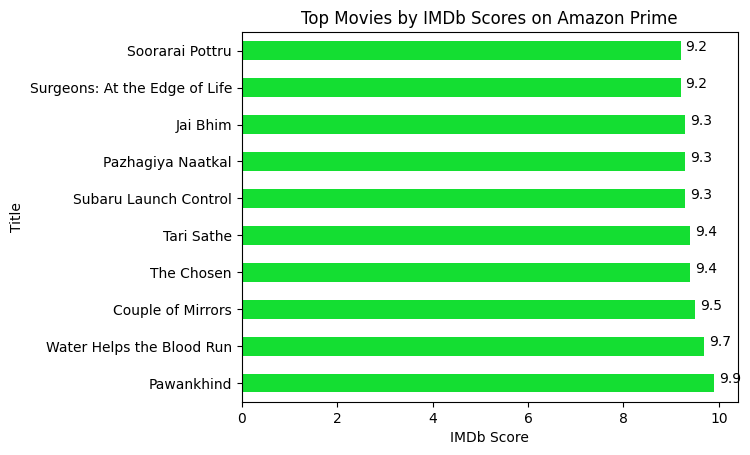

In [33]:
ax = top_10_shows.plot(
    x='title', y='imdb_score', kind='barh',
    title='Top IMDb Scores on Amazon Prime',
    color=['#14de32'], legend=False
)

ax.set_xlabel('IMDb Score')
ax.set_ylabel('Title')
ax.set_title('Top Movies by IMDb Scores on Amazon Prime')


for i, v in enumerate(top_10_shows['imdb_score']):
    ax.text(v + 0.1, i, str(v), color='black', fontsize=10)


plt.show()

##### 1. Why did you pick the specific chart?

This chart is help for analyzing the movie rating.

##### 2. What is/are the insight(s) found from the chart?

This chart indicates that the movie Pawankind has the highest imdb rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 This insight is valuable as it says that most of the movies in Amazon Prime have high imdb rating.

#### Chart - 2 - Top 10 Genres by count on Amazon Prime Video

In [34]:
genre_counts = df_exploded.groupby("genres").size().reset_index(name="count").head(10).sort_values(by="count", ascending=False)

In [35]:
genre_counts

,genres,count
6,drama,4762
3,comedy,2987
1,action,1820
4,crime,1250
5,documentation,1096
8,family,751
7,european,712
9,fantasy,554
2,animation,475
0,Unknown,209


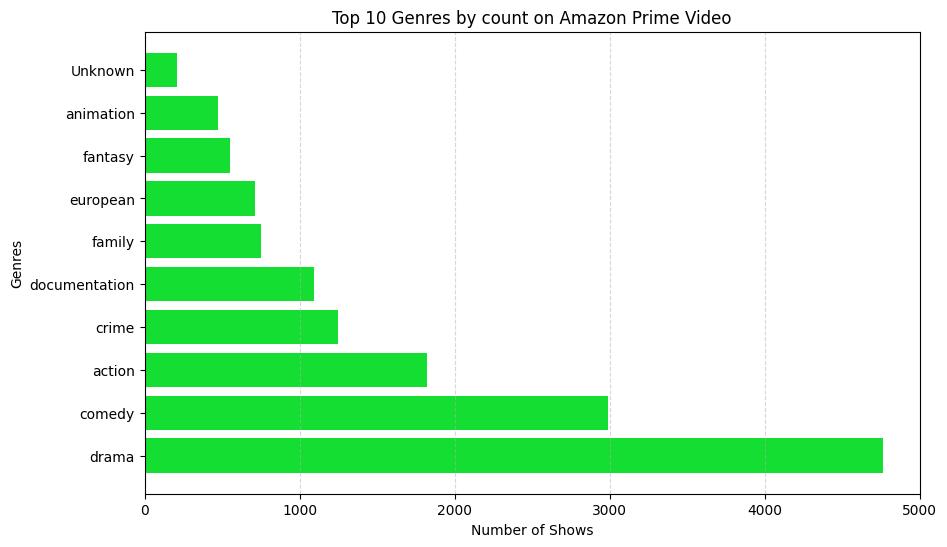

In [36]:
plt.figure(figsize=(10, 6))
plt.barh(genre_counts["genres"], genre_counts["count"], color="#14de32")

plt.xlabel("Number of Shows")
plt.ylabel("Genres")
plt.title("Top 10 Genres by count on Amazon Prime Video")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

We can understand that Drama genre has most of the movies.

##### 2. What is/are the insight(s) found from the chart?

There are many insights, one of the information is that the animation genres and unknown are least number of movies among top 10.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 This insight is valuable as it says that most of the genres in Amazon Prime have average number of movies.

#### Chart - 3 - Top 10 Countries by Content Production on Amazon Prime

In [37]:
region_counts = df_exploded_production_countries.groupby("production_countries").size().reset_index(name="count").head(10).sort_values(by="count", ascending=False)


In [38]:
region_counts

,production_countries,count
0,,821
9,AU,173
7,AR,23
8,AT,13
1,AE,8
2,AF,7
3,AL,2
4,AM,1
5,AN,1
6,AQ,1


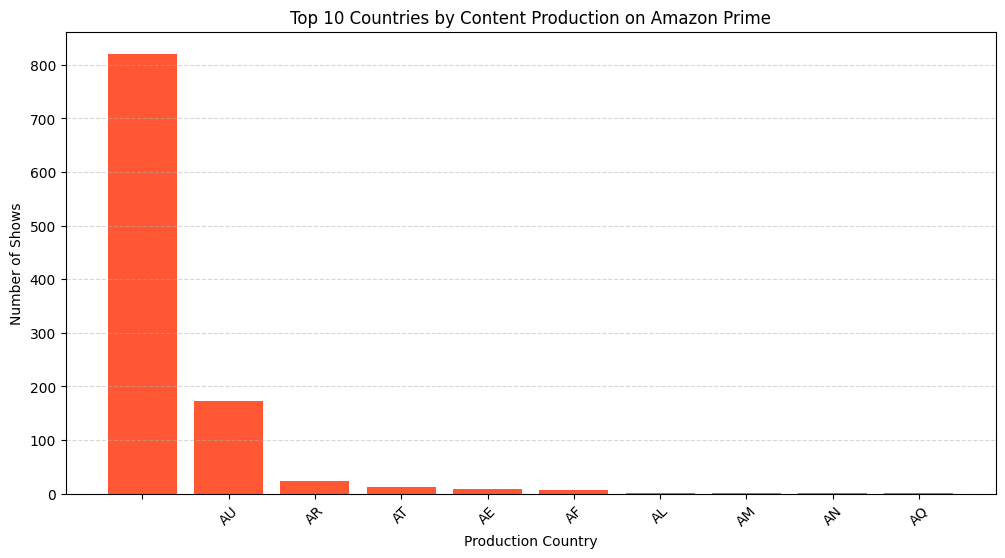

In [39]:
plt.figure(figsize=(12, 6))
plt.bar(region_counts["production_countries"], region_counts["count"], color="#FF5733")

plt.xlabel("Production Country")
plt.ylabel("Number of Shows")
plt.title("Top 10 Countries by Content Production on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

The information in the chart is easy to understand.

##### 2. What is/are the insight(s) found from the chart?

We can understand that the AU has more number of content distribution vary across.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart is useful for analyzing the number of movies distributes in different country.



#### Chart - 4 - Evolution of Amazon Prime Video Content Library Over Time

In [40]:
content_by_year = df_titles.groupby("release_year").size().reset_index(name="count")

In [41]:
content_by_year

,release_year,count
0,1912,1
1,1914,2
2,1915,5
3,1916,2
4,1917,1
...,...,...
105,2018,685
106,2019,807
107,2020,698
108,2021,856


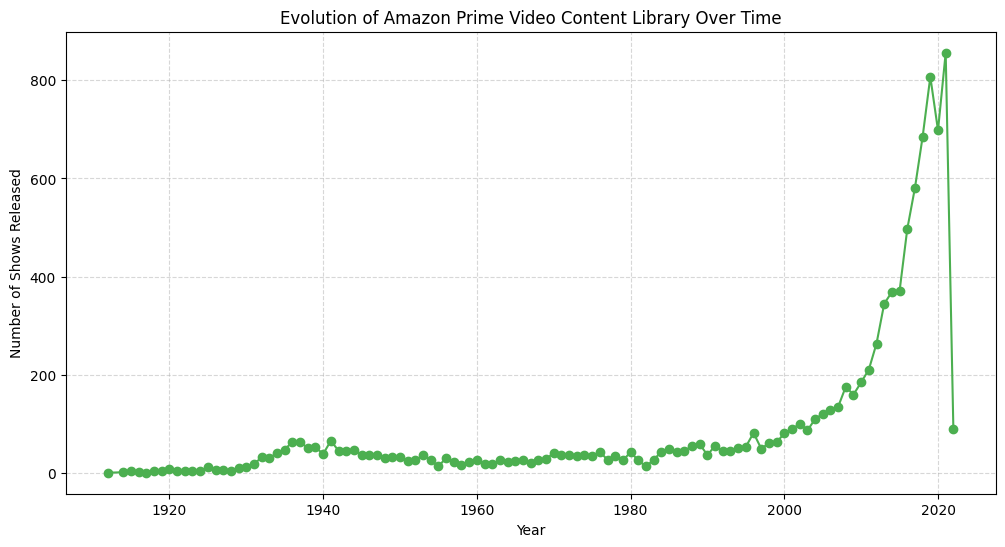

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(content_by_year["release_year"], content_by_year["count"], marker="o", color="#4CAF50")


plt.xlabel("Year")
plt.ylabel("Number of Shows Released")
plt.title("Evolution of Amazon Prime Video Content Library Over Time")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

The information in the chart is easy to understand.

##### 2. What is/are the insight(s) found from the chart?

We can understand that the 2010 there are more number of movie  across country.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart is valuable for analyzing movies year by year. It shows that in 2019, there was a decline, but after that, Amazon Prime experienced a resurgence and growth.

#### Chart - 5 - Top Movies by TMDb Scores on Amazon Prime

In [43]:
# Chart - 5 visualization code

In [44]:
tmdbtop_20_shows = df_titlescleaned.sort_values(by="tmdb_score", ascending=False).head(20)[["title", "tmdb_score"]]

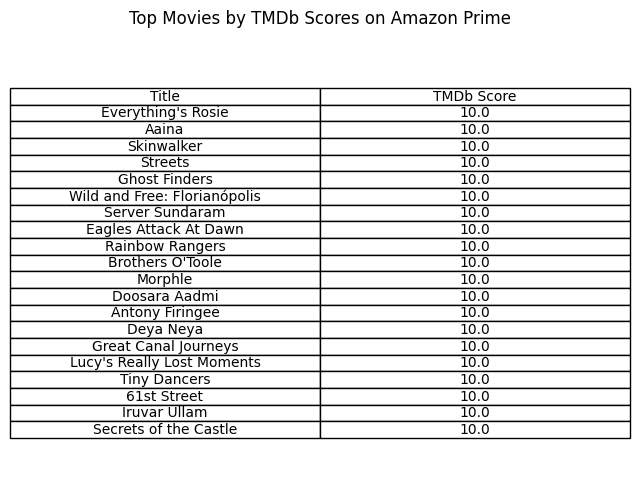

In [45]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('tight')
ax.axis('off')

table_data = tmdbtop_20_shows[['title', 'tmdb_score']].values
column_labels = ['Title', 'TMDb Score']

table = ax.table(cellText=table_data, colLabels=column_labels, cellLoc='center', loc='center')

plt.title('Top Movies by TMDb Scores on Amazon Prime')
plt.show()

##### 1. Why did you pick the specific chart?

The table representation allows us to observe that there are over 20 movies with a TMDb score of 10.

##### 2. What is/are the insight(s) found from the chart?

It is challenging to determine which movie is better than the others since all the movies have the same score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The score could have a negative impact on users, as it might mislead viewers into thinking that all the movies are equally the best, given that they all have a score of 10.

#### Chart - 6 - Top 10 movies by Tmdb Popularity on Amazon Prime

In [46]:
# Chart - 6 visualization code

In [47]:
top10tmdb_popularity = df_titlescleaned.sort_values(by="tmdb_popularity", ascending=False).head(20)[["title", "tmdb_popularity"]]

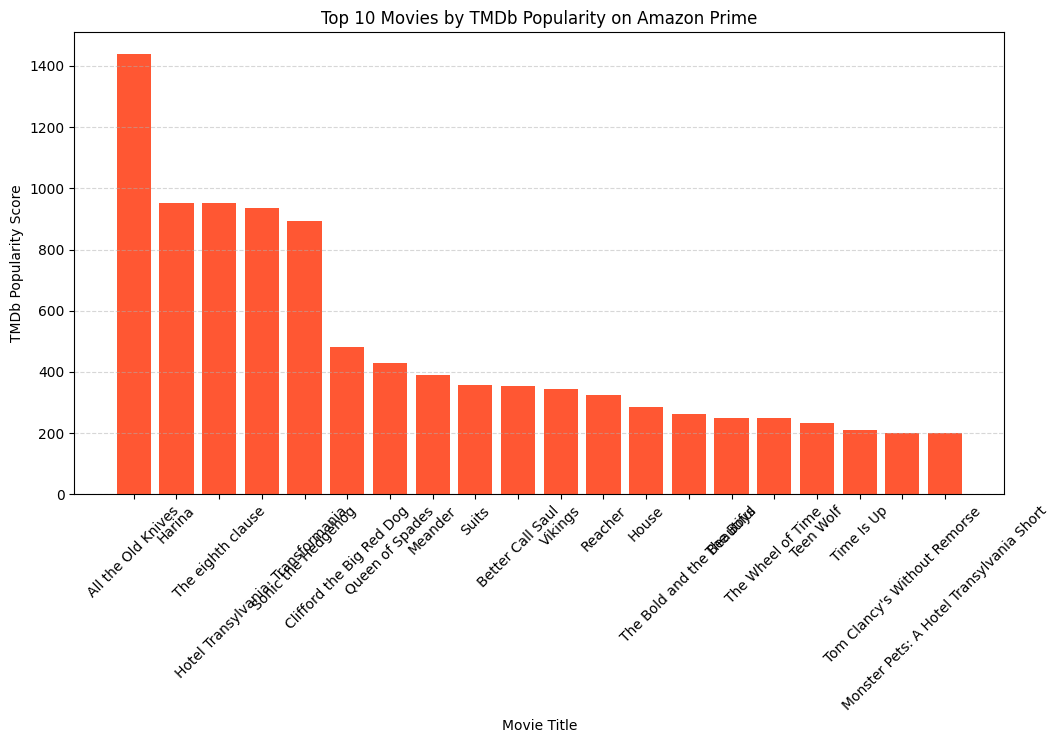

In [48]:
plt.show()
plt.figure(figsize=(12, 6))
plt.bar(top10tmdb_popularity["title"], top10tmdb_popularity["tmdb_popularity"], color="#FF5733")

plt.xlabel("Movie Title")
plt.ylabel("TMDb Popularity Score")
plt.title("Top 10 Movies by TMDb Popularity on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart provides an easier way to understand the popularity of the top 10 movies.

##### 2. What is/are the insight(s) found from the chart?

We can see that All the Old Knives is popular, as the previous chart made it difficult to identify the best movie based solely on the score. This chart helps us easily identify the most popular movie.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We can see that All the Old Knives is popular, as the previous chart made it difficult to identify the best movie based solely on the score. This chart helps us easily identify the most popular movie.

#### Chart - 7 - Top 10 Actors with the Most Movie on Amazon Prime

In [49]:
# Chart - 7 visualization code - Top 10 Actors with the Most Movie on Amazon Prime

In [50]:
top_10_actors= df_credits[df_credits['role']=='ACTOR'].groupby("name")['id'].nunique().reset_index().sort_values(by="id", ascending=False).head(10)

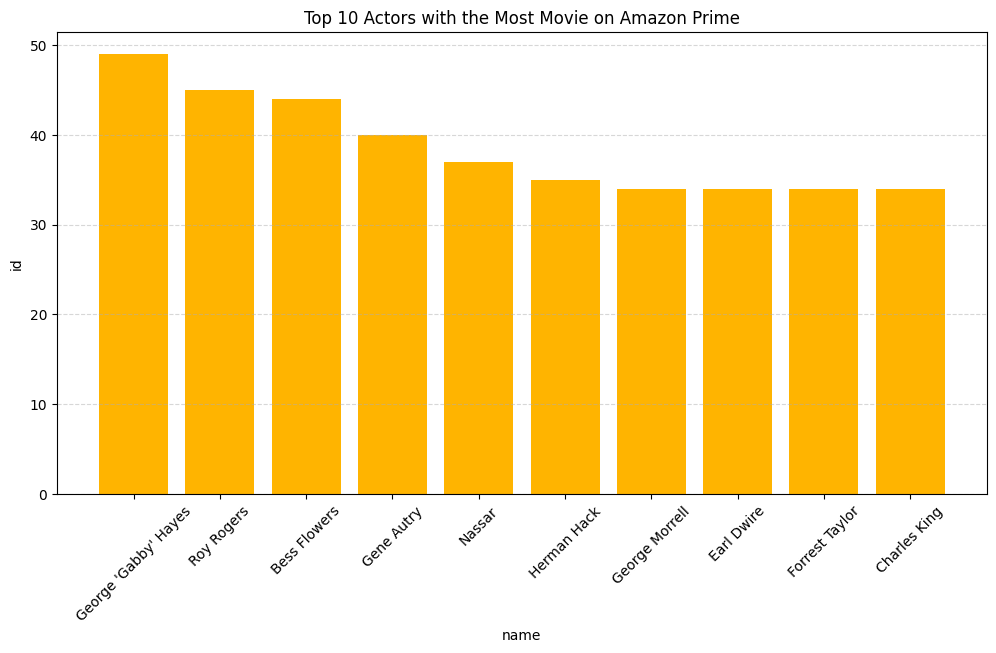

In [51]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_actors["name"], top_10_actors["id"], color="#FFB400")

plt.xlabel("name")
plt.ylabel("id")
plt.title("Top 10 Actors with the Most Movie on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

The bar chart highlights the actors with the highest number of movies on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

We can see that George 'Gabby' Hayes is a featured actor followed by Roy Rogers and Bess Flowers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows the actors with the highest number of films available on Amazon Prime.

#### Chart - 8 - Top 10 Directors with the Most Movie on Amazon Prime

In [52]:
# Chart - 8 visualization code

In [53]:
top_10_directors= df_credits[df_credits['role']=='DIRECTOR'].groupby("name")['id'].nunique().reset_index().sort_values(by="id", ascending=False).head(10)

In [54]:
top_10_directors

,name,id
2998,Joseph Kane,41
5208,Sam Newfield,38
2551,Jay Chapman,34
3450,Lesley Selander,22
2154,Harry L. Fraser,21
2808,John English,21
6152,William Nigh,20
3647,Manny Rodriguez,17
5001,Robert N. Bradbury,17
6117,William Beaudine,16


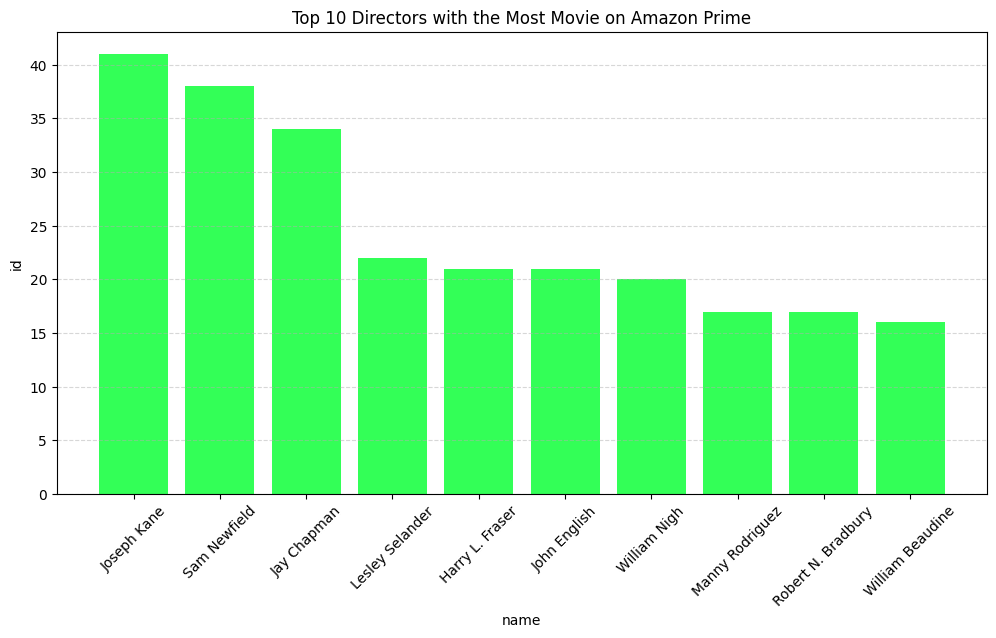

In [55]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_directors["name"], top_10_directors["id"], color="#33FF57")
plt.xlabel("name")
plt.ylabel("id")
plt.title("Top 10 Directors with the Most Movie on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

The bar chart highlights the directors with the highest number of movies on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

We can see that Joseph Kane is a top director followed by Sam Newfield and Jay Chapman.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows the directors with the highest number of films available on Amazon Prime.

#### Chart - 9 - Top 10 Movies by Directors on Amazon Prime

In [56]:
# Chart - 9 visualization code

In [57]:
top_10_movies = (
    join_df[join_df['role'] == 'DIRECTOR']
    .sort_values(by="imdb_score", ascending=False)
    .head(10)
)

In [58]:
top_10_movies

,person_id,id,name,character,role,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
119049,1547139,tm1159926,Digpal Lanjekar,NaN,DIRECTOR,Pawankhind,MOVIE,The story of the Maratha Warriors at the battl...,2022,NaN,153,"action, drama, history",IN,NaN,tt14448632,9.9,2036.0,3.812,8.5
123022,206328,tm1062504,T S Suresh Babu,NaN,DIRECTOR,Pazhagiya Naatkal,MOVIE,NaN,2021,NaN,127,drama,,NaN,tt14747784,9.3,58.0,NaN,NaN
117973,157394,tm1108724,T. J. Gnanavel,NaN,DIRECTOR,Jai Bhim,MOVIE,A pregnant woman from a primitive tribal commu...,2021,NaN,164,"drama, crime",IN,NaN,tt15097216,9.3,175187.0,6.051,7.4
107026,235050,tm810763,Sudha Kongara Prasad,NaN,DIRECTOR,Soorarai Pottru,MOVIE,"Nedumaaran Rajangam ""Maara"" sets out to make t...",2020,NaN,149,"drama, action",IN,NaN,tt10189514,9.2,109759.0,4.146,7.9
108990,1679829,tm905419,P. Amudhavanan,NaN,DIRECTOR,Quota,MOVIE,"""Quota"" is all about the underprivileged child...",2020,G,101,"family, drama",IN,NaN,tt12077850,9.2,306.0,0.692,4.0
114645,1869733,tm546268,Rehmat Rayatt,NaN,DIRECTOR,Toxification,MOVIE,"Toxification of land, body and mind examines t...",2020,NaN,66,documentation,IN,NaN,tt5495060,9.1,14.0,0.600,NaN
110369,165847,tm244275,Ram,NaN,DIRECTOR,Peranbu,MOVIE,"A single father tries to raise his daughter, w...",2019,NaN,147,drama,IN,NaN,tt7738784,9.1,14708.0,2.508,7.9
96737,1411049,ts83241,Sruti Harihara Subramanian,NaN,DIRECTOR,Harmony with A. R. Rahman,SHOW,Harmony with A.R Rahman' is a curated explorat...,2018,NaN,43,documentation,IN,1.0,tt8836898,9.1,277.0,0.647,NaN
34872,56156,tm134266,Tom McLoughlin,NaN,DIRECTOR,Steven Banks: Home Entertainment Center,MOVIE,"In this brilliant one-man show, the mild-manne...",1989,NaN,60,comedy,US,NaN,tt0443654,9.1,228.0,0.740,6.4
114644,1870618,tm546268,Leva Kwestany,NaN,DIRECTOR,Toxification,MOVIE,"Toxification of land, body and mind examines t...",2020,NaN,66,documentation,IN,NaN,tt5495060,9.1,14.0,0.600,NaN


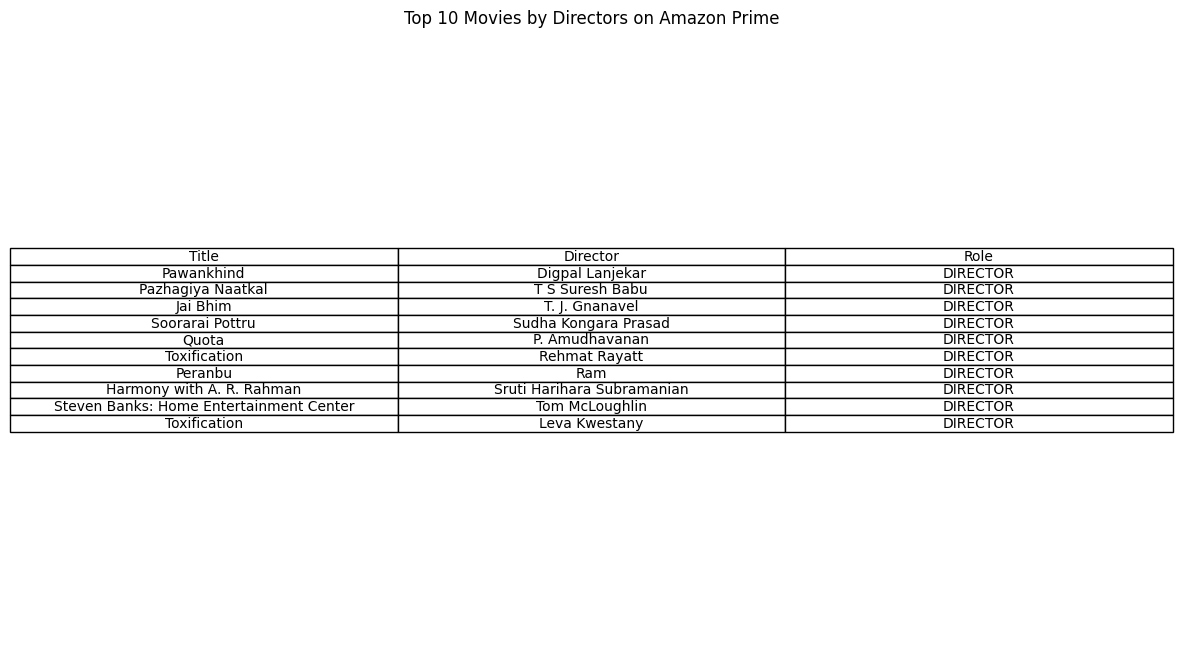

In [59]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.axis('tight')
ax.axis('off')

table_data = top_10_movies[['title', 'name','role']].values
column_labels = ['Title', 'Director', 'Role']

table = ax.table(cellText=table_data, colLabels=column_labels, cellLoc='center', loc='center')

plt.title('Top 10 Movies by Directors on Amazon Prime')
plt.show()

##### 1. Why did you pick the specific chart?

The table helps us understand which director has created the most successful films

##### 2. What is/are the insight(s) found from the chart?

We can see that Digpal Lanjekar is a top director followed by T S Suresh Babu and T J Gnanavel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart highlights the directors whose films have the highest IMDb scores on Amazon Prime.

#### Chart - 10 - Average Imdb score with the Directors on Amazon Prime

In [60]:
# Chart - 10 visualization code

In [61]:
top_10_imdb_directors = (
    join_df[join_df['role'] == 'DIRECTOR']
    .groupby("name")['imdb_score']
    .mean()
    .reset_index()
    .sort_values(by="imdb_score", ascending=False)
    .head(10)
)


In [62]:
top_10_imdb_directors

,name,imdb_score
1494,Digpal Lanjekar,9.9
5662,T S Suresh Babu,9.3
5663,T. J. Gnanavel,9.3
4383,P. Amudhavanan,9.2
1935,Gavin Whitehead,9.1
4819,Rehmat Rayatt,9.1
5483,Sruti Harihara Subramanian,9.1
4744,Ram,9.1
3462,Leva Kwestany,9.1
5065,Rojin Thomas,9.0


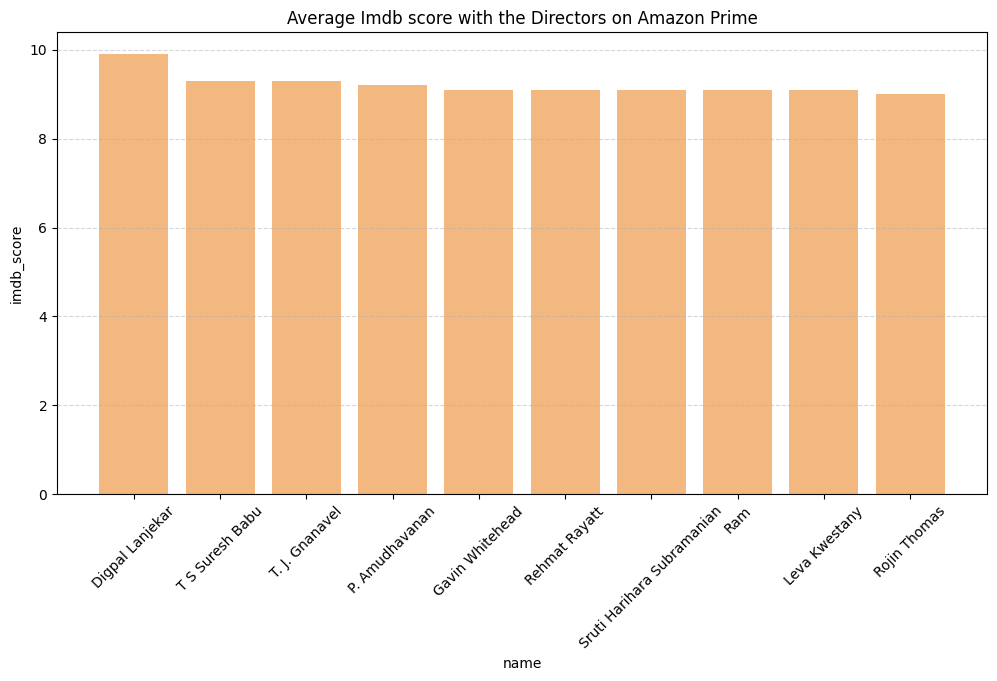

In [63]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_imdb_directors["name"], top_10_imdb_directors["imdb_score"], color="#F2B880")
plt.xlabel("name")
plt.ylabel("imdb_score")
plt.title("Average Imdb score with the Directors on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps us to understand the Average Imdb score with the Directors on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

We can see that Digpal Lanjekar is a top director followed by T S Suresh Babu and T J Gnanavel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart highlights the directors whose overall films have the highest IMDb scores on Amazon Prime.

#### Chart - 11 - Bottom 10 Directors by imdb score on Amazon Prime

In [64]:
# Chart - 11 visualization code

In [65]:
Bottom_10_imdb_directors = (
    join_df[join_df['role'] == 'DIRECTOR']
    .groupby("name")['imdb_score']
    .mean()
    .reset_index()
    .sort_values(by="imdb_score", ascending=True)
    .loc[lambda x: x['imdb_score'] < 2]
    .head(10)
)


In [66]:
Bottom_10_imdb_directors

,name,imdb_score
2540,Jason Wright,1.1
1274,Darren Doane,1.3
443,Armen Adilkhanyan,1.5
5262,Sasha Burrow,1.6
2874,John Riggins,1.6
1225,Daniel H. Torrado,1.7
4154,Nabil Elderkin,1.7
5792,Tim Ritter,1.8
42,Adam Berardi,1.8
1282,Dave Flocker,1.8


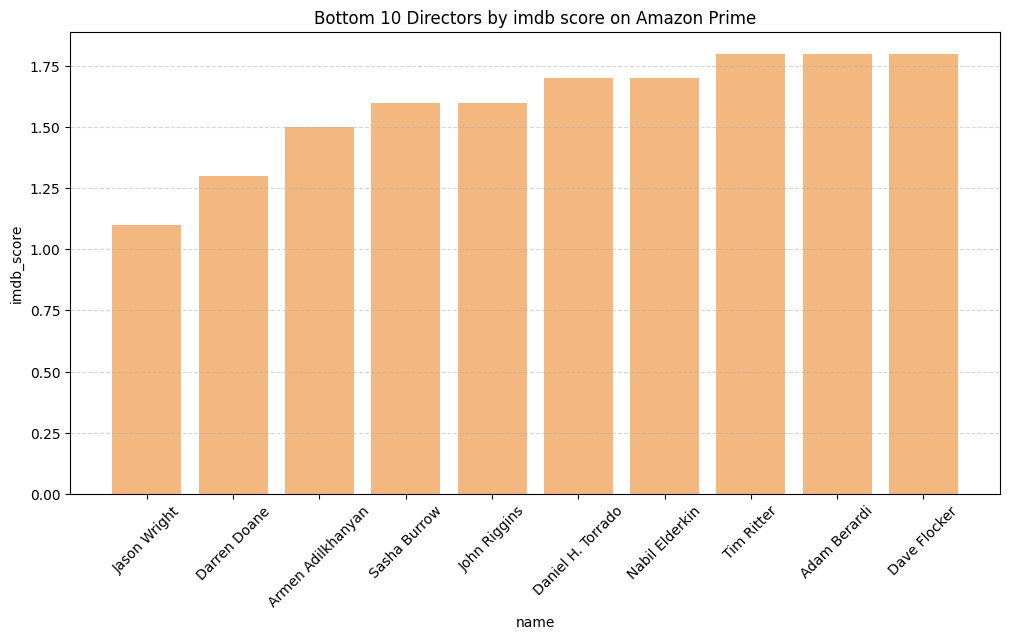

In [67]:
plt.figure(figsize=(12, 6))
plt.bar(Bottom_10_imdb_directors["name"], Bottom_10_imdb_directors["imdb_score"], color="#F2B880")
plt.xlabel("name")
plt.ylabel("imdb_score")
plt.title("Bottom 10 Directors by imdb score on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps us to understand the Bottom Imdb score with the Directors on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

We can see that Jason Wright is a bottom director followed by Darren Doane and Armen Adikhanyan.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart highlights the directors whose overall films have the lowest IMDb scores on Amazon Prime.

#### Chart - 12 - Bottom 10 Actors by imdb score on Amazon Prime

In [68]:
# Chart - 12 visualization code

In [69]:
Bottom_10_imdb_actors = (
    join_df[join_df['role'] == 'ACTOR']
    .groupby("name")['imdb_score']
    .mean()
    .reset_index()
    .sort_values(by="imdb_score", ascending=True)
    .loc[lambda x: x['imdb_score'] < 2]
    .head(10)
)


In [73]:
Bottom_10_imdb_actors

,name,imdb_score
32550,Jerry Davis,1.1
40877,Lanny Norris,1.1
15881,Darren Richardson,1.1
71246,Victor Merchan,1.1
68994,Tina Shuster,1.1
43111,Lizzy Carter-Burns,1.1
879,Aidan McCreary,1.1
5037,Antonio Zequila,1.2
51883,Nello Iorio,1.2
25136,Giucas Casella,1.2


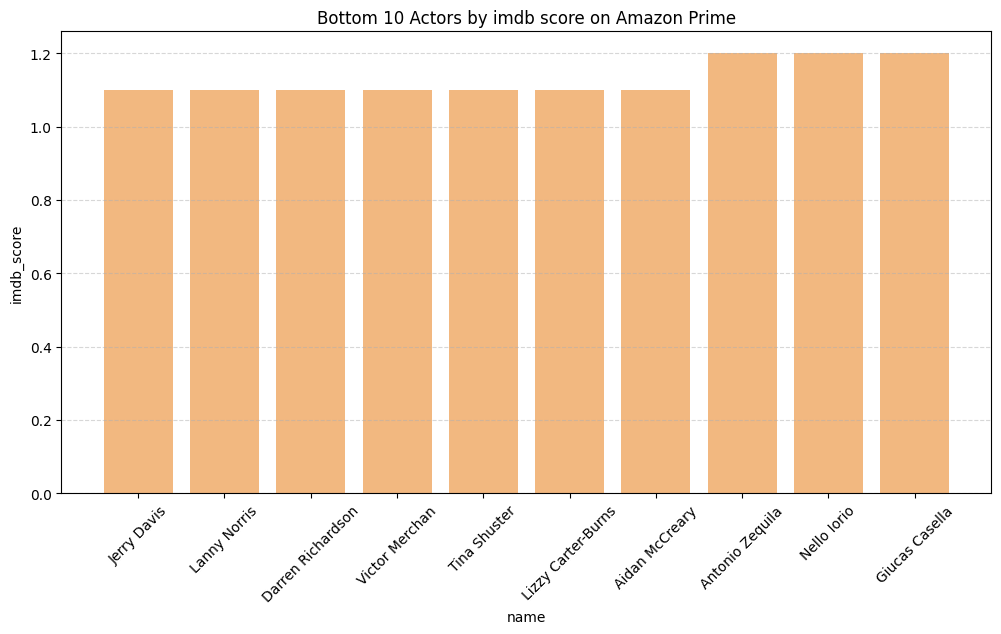

In [74]:
plt.figure(figsize=(12, 6))
plt.bar(Bottom_10_imdb_actors["name"], Bottom_10_imdb_actors["imdb_score"], color="#F2B880")
plt.xlabel("name")
plt.ylabel("imdb_score")
plt.title("Bottom 10 Actors by imdb score on Amazon Prime")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps us to understand the Bottom Imdb score with the Actors on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?

We can see that Jerry Davis is a bottom actor followed by Lanny Norris and Darren Richardson.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart highlights the actors whose overall films have the lowest IMDb scores on Amazon Prime.

#### Chart - 13 - Pair Plot

In [72]:
# Pair Plot visualization code

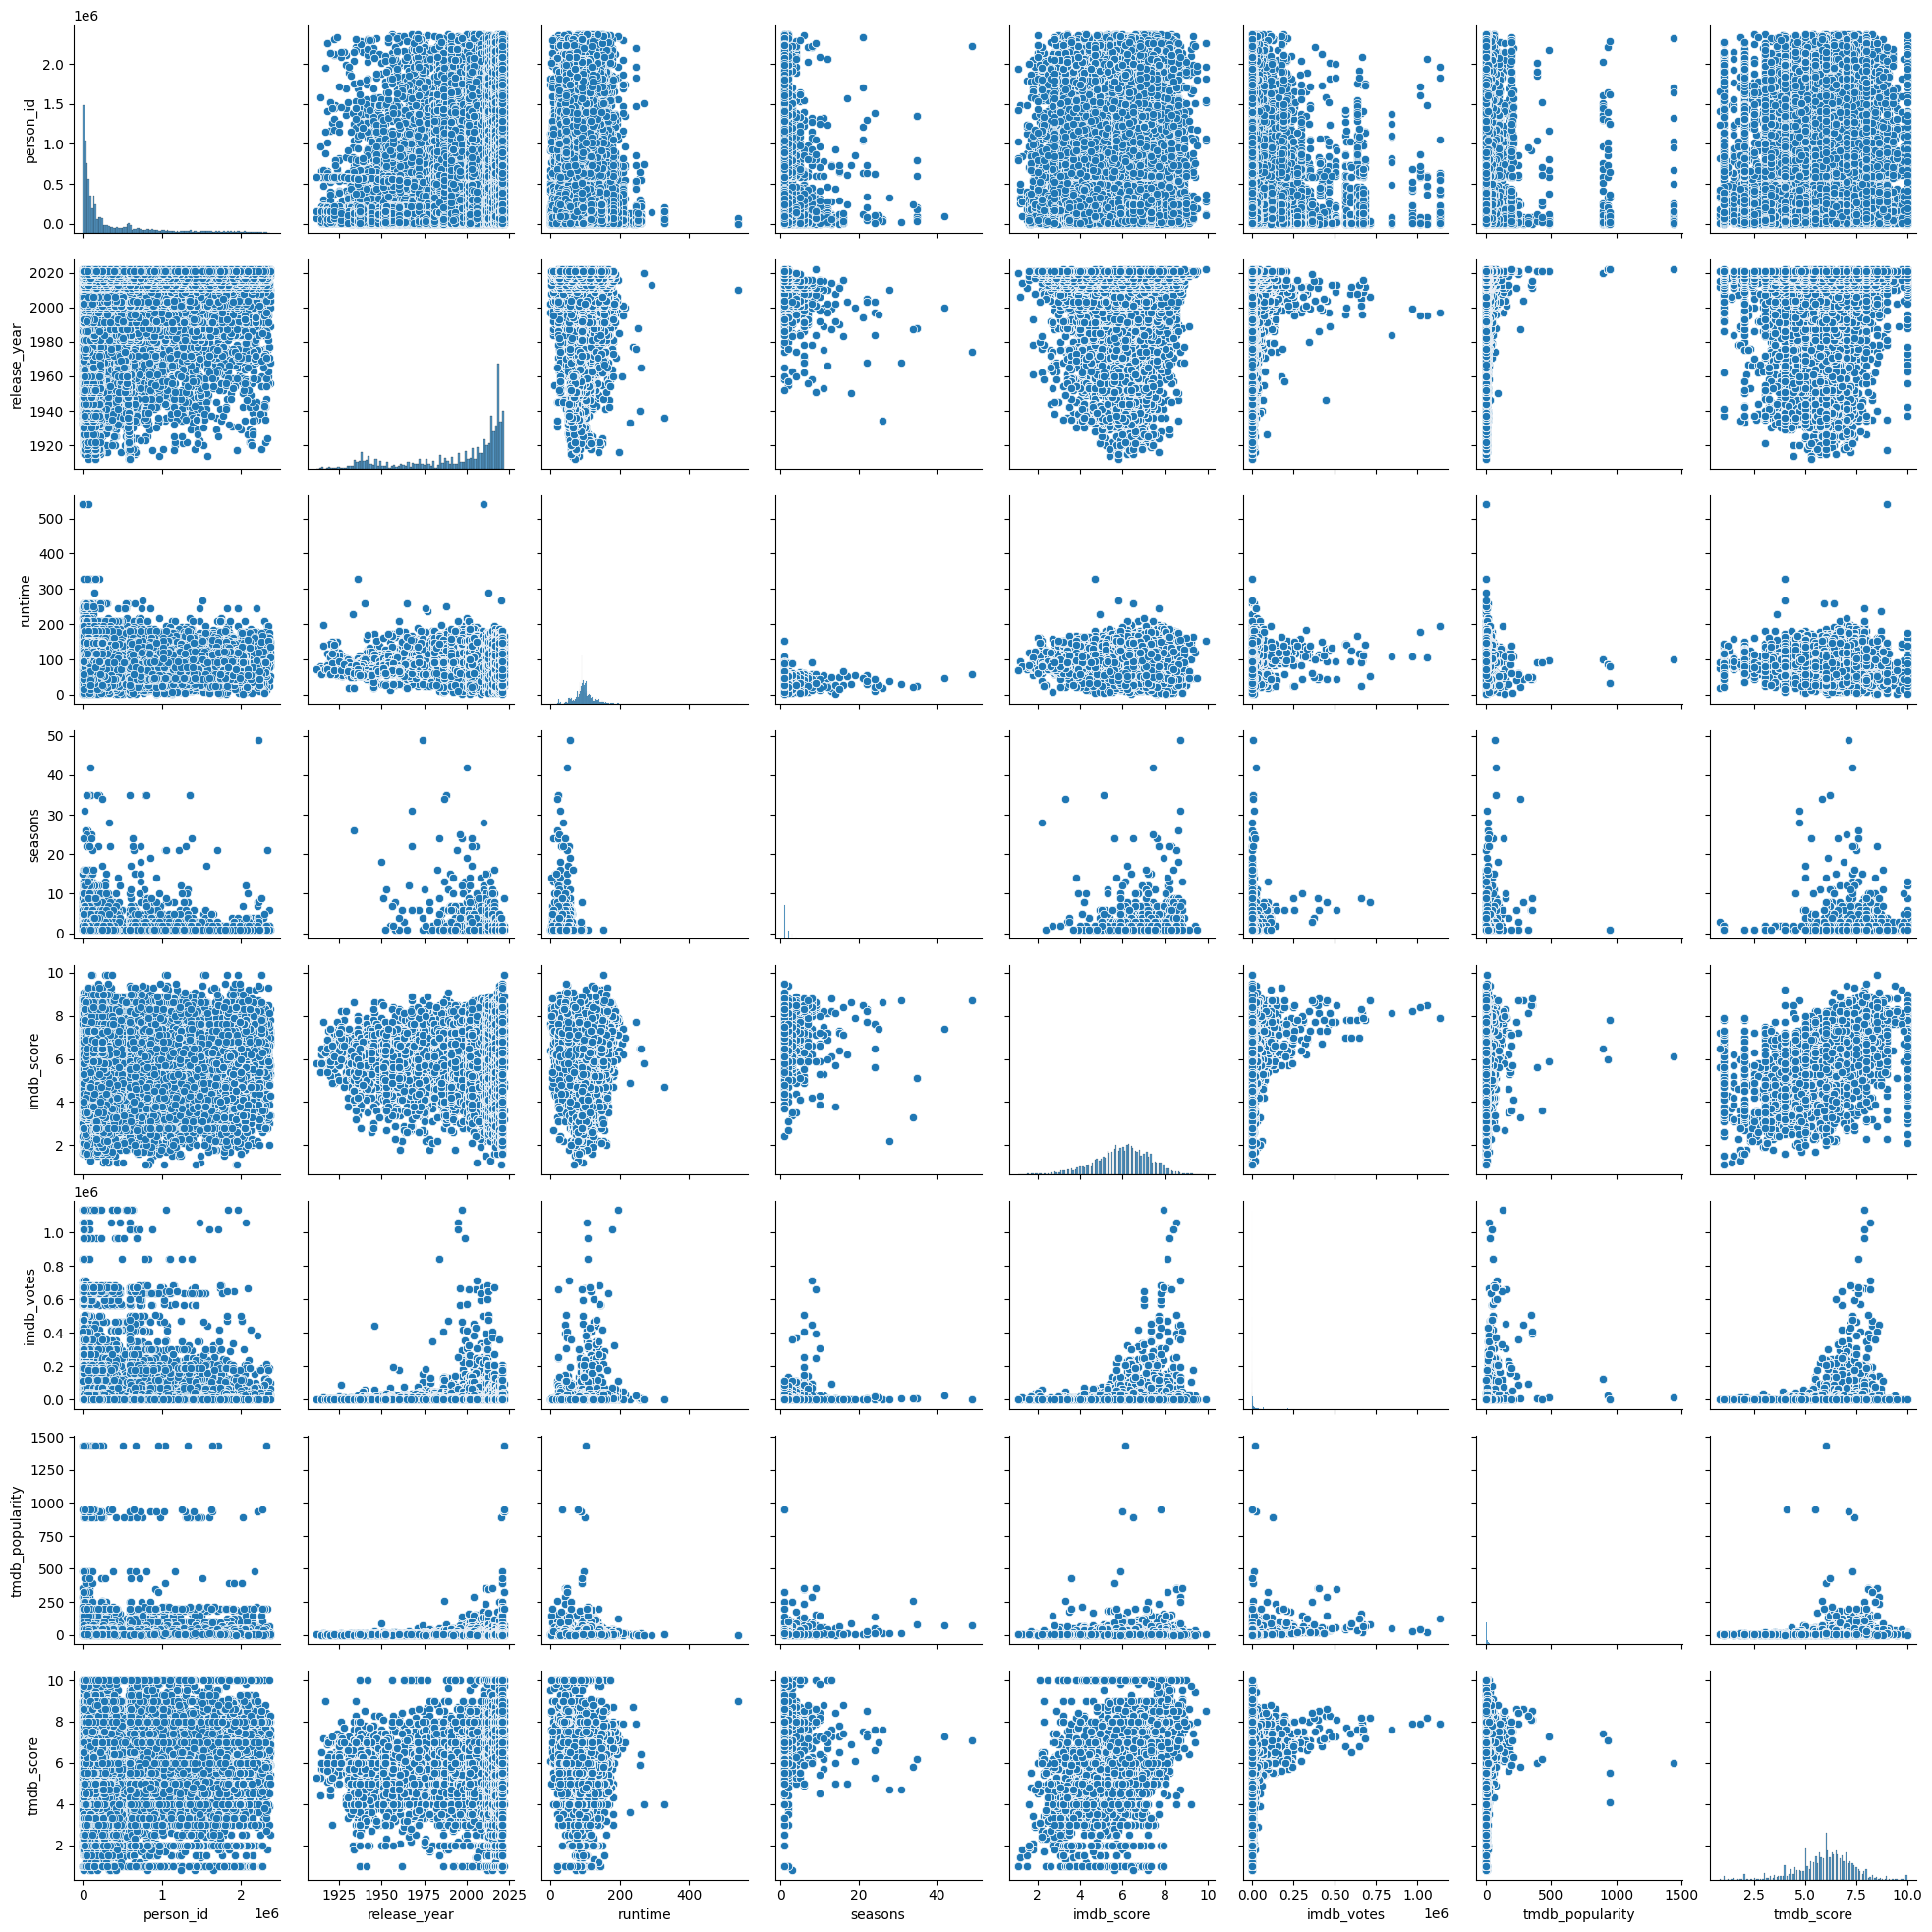

In [76]:
sns.pairplot(join_df)
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps to find the relationship between each numeric field.

##### 2. What is/are the insight(s) found from the chart?

Person ID shows a stronger relationship with runtime and seasons compared to other variables.

This suggests that certain individuals (directors, actors, or creators) may be associated with longer projects or multi-season shows.
Release Year is linked to both runtime and the number of seasons.

This could indicate that newer productions tend to have longer durations or more seasons.
A strong correlation exists between runtime and seasons.

Shows with longer runtimes are more likely to have multiple seasons.
Seasons and IMDb score also show a noticeable relationship.

This implies that series with more seasons might receive higher ratings.
Runtime and IMDb score appear to be connected.

Longer movies or shows might generally receive better ratings.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

When advising a client on achieving a business objective related to Amazon Prime, the recommendations depend on their specific goals, such as increasing subscriptions, engagement, revenue, or content performance.

# **Conclusion**

The analysis of Amazon Prime's movie dataset provided valuable insights into the platform's content, highlighting trends related to actors, directors, IMDb ratings, and overall movie distribution.
The most featured actors on Amazon Prime were identified, with George 'Gabby' Hayes leading in terms of movie appearances.
Directors with the highest average IMDb scores were also highlighted, showing those who consistently create well-received films.
This project helped uncover the most prominent actors (George 'Gabby' Hayes), directors (Digpal Lanjekar ), and highest-rated movies (Pawankind) on Amazon Prime.